# Initialisation Check

This notebook visualises the initial parameter vector $\theta^{(0)}$ computed by `src/em_initialization.py`, as a sanity check before running the EM algorithm. See Section 4 of the thesis.

**Files loaded:**
- `data/processed/theta_initial.npz` — arrays $\Lambda$, $A$, $Q$, $R$, $F$, $\nu$
- `data/processed/theta_initial_metadata.json` — sample dimensions and eigenvalue summaries

In [6]:
import pathlib
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── CONFIG SWITCH ─────────────────────────────────────────────────────────────
# Which configuration's initialisation (theta_initial) to inspect:
#   "small" → 20 series   "big" → 50 series
# All paths and block assignments are derived from this single variable.
CONFIG = "big"     # <-- change to "big"

# ── paths ─────────────────────────────────────────────────────────────────────
ROOT = pathlib.Path().resolve().parent
PROC = ROOT / "data" / "processed"
NPZ_PATH  = PROC / CONFIG / "theta_initial.npz"
JSON_PATH = PROC / CONFIG / "theta_initial_metadata.json"
CSV_PATH  = PROC / f"dataset_{CONFIG}.csv"

# ── config-driven block assignment (single source of truth) ──────────────────
src_dir = str(ROOT / "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)
from data_loader import load_config

cfg          = load_config(CONFIG)
ORDERED_COLS = cfg["ORDERED_COLS"]
BLOCK        = cfg["BLOCK"]

# ── load arrays ───────────────────────────────────────────────────────────────
npz  = np.load(NPZ_PATH)
Lambda  = npz["Lambda"]   # (M, r)
A       = npz["A"]        # (r, r)
Q       = npz["Q"]        # (r, r)
R       = npz["R"]        # (M,)
F       = npz["F"]        # (T, r)
nu_u    = float(npz["nu_u"])
nu_eps  = float(npz["nu_eps"])

# ── load metadata ─────────────────────────────────────────────────────────────
with open(JSON_PATH, encoding="utf-8") as fh:
    meta = json.load(fh)

# ── load dataset (for names and dates) ────────────────────────────────────────
df = pd.read_csv(CSV_PATH, index_col=0, parse_dates=True)
series_names = list(df.columns)   # canonical order (== ORDERED_COLS)
dates        = df.index           # DatetimeIndex, monthly

# ── summary ───────────────────────────────────────────────────────────────────
print(f"Config : {CONFIG}")
print(f"Sample : {meta['sample_start']}  \u2192  {meta['sample_end']}")
print(f"T={meta['T']}, M={meta['M']}, r={meta['r']}")
print(f"Block sizes: {meta['block_sizes']}")
print(f"\nShapes loaded:")
print(f"  Lambda : {Lambda.shape}")
print(f"  A      : {A.shape}")
print(f"  Q      : {Q.shape}")
print(f"  R      : {R.shape}")
print(f"  F      : {F.shape}")
print(f"\nnu_u = {nu_u},  nu_eps = {nu_eps}")

Config : big
Sample : 1985-01-31  →  2026-06-30
T=498, M=50, r=3
Block sizes: {'real': 22, 'financial': 18, 'other': 10}

Shapes loaded:
  Lambda : (50, 3)
  A      : (3, 3)
  Q      : (3, 3)
  R      : (50,)
  F      : (498, 3)

nu_u = 10.0,  nu_eps = 10.0


## 1. Loading matrix $\Lambda^{(0)}$ (block-diagonal)

The loading matrix $\Lambda \in \mathbb{R}^{M \times r}$ links each of the $M=20$ observed series to the $r=3$ latent factors $(f_R, f_F, f_X)$. Under the block-diagonal restriction (Section 8 of the thesis), series belonging to the **real** block load only on $f_R$, **financial** series on $f_F$, and **other** series on $f_X$. All off-block entries are exactly zero by construction.

The heatmap below should show three non-zero "stripes" aligned with the block structure, and white (zero) everywhere else.

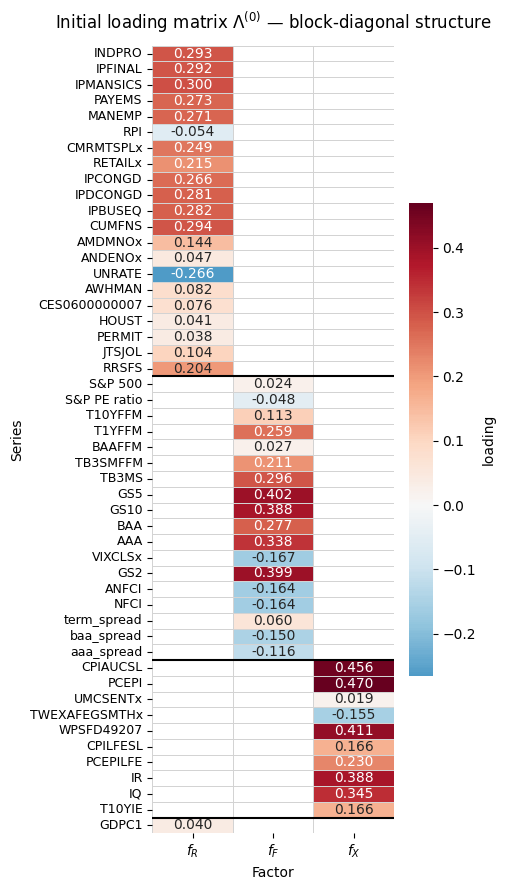

In [7]:
factor_labels = [r"$f_R$", r"$f_F$", r"$f_X$"]

fig, ax = plt.subplots(figsize=(5, 9))

# mask exactly-zero cells so they appear white
mask = (Lambda == 0.0)

sns.heatmap(
    Lambda,
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.4,
    linecolor="lightgrey",
    xticklabels=factor_labels,
    yticklabels=series_names,
    ax=ax,
    cbar_kws={"label": "loading", "shrink": 0.6},
)

# draw block separator lines wherever the block changes along the column order
for _i in range(1, len(series_names)):
    if BLOCK[series_names[_i]] != BLOCK[series_names[_i - 1]]:
        ax.axhline(_i, color="black", lw=1.5)

ax.set_title(r"Initial loading matrix $\Lambda^{(0)}$ — block-diagonal structure",
             pad=12)
ax.set_xlabel("Factor")
ax.set_ylabel("Series")
ax.yaxis.set_tick_params(labelsize=9)

fig.tight_layout()
plt.show()

## 2. Initial factors $F^{(0)}$

The three factors are extracted by block-by-block PCA (Section 4.2). Each factor is the first principal component of its sub-panel:
- $f_R$: real activity (IP, payrolls, retail sales, GDP)
- $f_F$: financial conditions (equities, spreads, NFCI)
- $f_X$: other (prices, sentiment, trade-weighted dollar)

As a sanity check, the factors should visibly contract during NBER recessions (shaded grey).

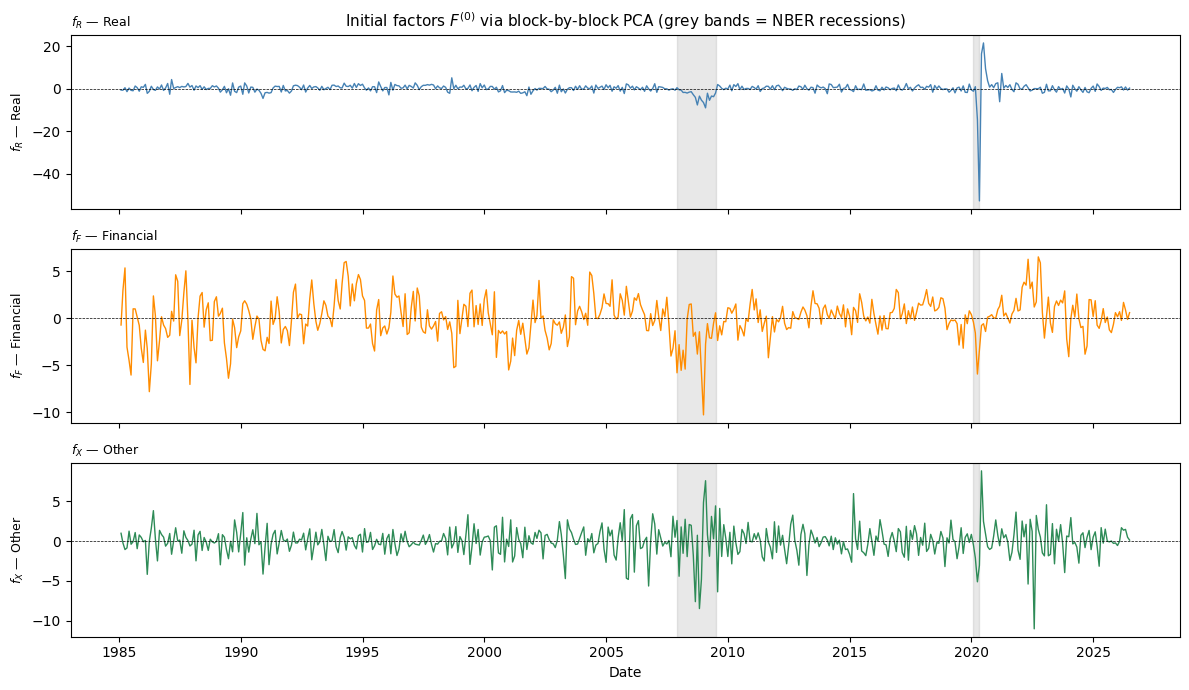

In [8]:
RECESSIONS = [("2007-12-01", "2009-06-30"), ("2020-02-01", "2020-04-30")]

factor_plot_labels = [
    r"$f_R$ — Real",
    r"$f_F$ — Financial",
    r"$f_X$ — Other",
]
colors = ["steelblue", "darkorange", "seagreen"]

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

for idx, (ax, label, color) in enumerate(zip(axes, factor_plot_labels, colors)):
    ax.plot(dates, F[:, idx], lw=1.0, color=color)
    ax.axhline(0, lw=0.5, ls="--", color="black")
    for r_start, r_end in RECESSIONS:
        ax.axvspan(pd.Timestamp(r_start), pd.Timestamp(r_end),
                   alpha=0.18, color="grey", zorder=0)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontsize=9, loc="left")

axes[-1].set_xlabel("Date")
axes[0].set_title(
    r"Initial factors $F^{(0)}$ via block-by-block PCA"
    " (grey bands = NBER recessions)",
    fontsize=11,
)

fig.tight_layout()
plt.show()

## 3. VAR(1) transition matrix $A^{(0)}$ — stability

The latent factors follow a VAR(1) process $f_t = A f_{t-1} + u_t$. For the model to be **covariance-stationary**, all eigenvalues of $A$ must lie strictly inside the unit circle, i.e. $|\lambda_j| < 1$ for $j = 1, 2, 3$.

The plot below shows the eigenvalues of $A^{(0)}$ in the complex plane together with the unit circle.

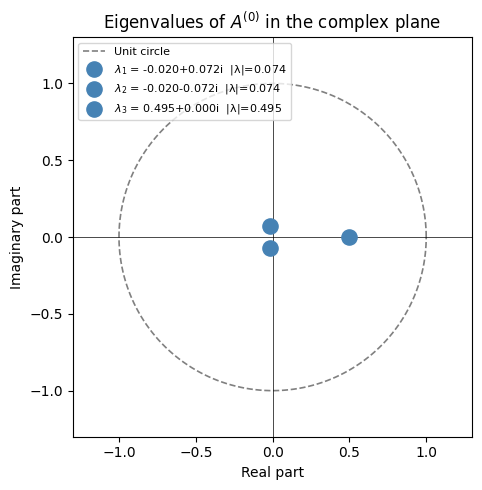

Eigenvalue moduli:
  |λ_1| = 0.074301  [stable]
  |λ_2| = 0.074301  [stable]
  |λ_3| = 0.494816  [stable]

VAR is STABLE (all moduli < 1: True)


In [9]:
eigvals = np.linalg.eigvals(A)
moduli  = np.abs(eigvals)

fig, ax = plt.subplots(figsize=(5, 5))

# unit circle
theta_circle = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(theta_circle), np.sin(theta_circle),
        lw=1.2, color="grey", ls="--", label="Unit circle")
ax.axhline(0, lw=0.5, color="black")
ax.axvline(0, lw=0.5, color="black")

# eigenvalues
for k, ev in enumerate(eigvals):
    stable = moduli[k] < 1.0
    color  = "steelblue" if stable else "crimson"
    marker = "o" if stable else "X"
    ax.scatter(ev.real, ev.imag, s=120, color=color, marker=marker,
               zorder=5, label=fr"$\lambda_{k+1}$ = {ev.real:.3f}{ev.imag:+.3f}i  |λ|={moduli[k]:.3f}")

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect("equal")
ax.set_xlabel("Real part")
ax.set_ylabel("Imaginary part")
ax.set_title(r"Eigenvalues of $A^{(0)}$ in the complex plane")
ax.legend(fontsize=8, loc="upper left")

fig.tight_layout()
plt.show()

print("Eigenvalue moduli:")
for k, mod in enumerate(moduli):
    status = "stable" if mod < 1.0 else "UNSTABLE"
    print(f"  |λ_{k+1}| = {mod:.6f}  [{status}]")

print(f"\nVAR is {'STABLE' if (moduli < 1).all() else 'UNSTABLE'} "
      f"(all moduli < 1: {(moduli < 1).all()})")

## 4. Idiosyncratic variances $R^{(0)}$

The diagonal of the idiosyncratic covariance $R_i = \mathrm{Var}(\varepsilon_{it})$ measures how much of each series' variance is **not** explained by its block factor. Because the series are standardised to unit variance, $R_i \in (0, 1]$ in principle:
- $R_i \approx 0$: the factor explains nearly all variation in series $i$ (high communality).
- $R_i \approx 1$: the factor explains very little; the series is mostly idiosyncratic.

Values above 1 can occur at initialisation because the PCA factors are not exactly OLS projections.

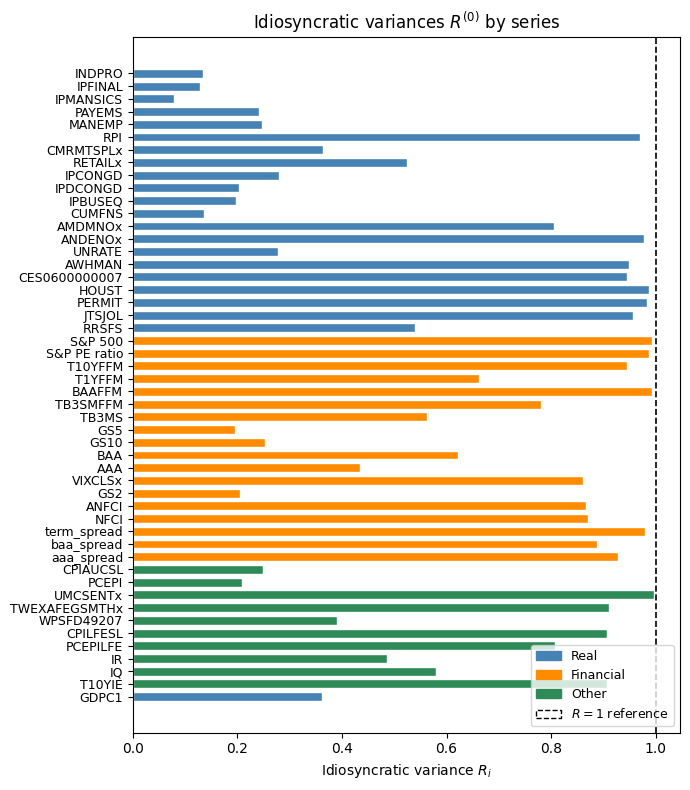

R range: [0.0795, 0.9965]
Series with R > 1: none


In [10]:
block_colors = {
    "real":      "steelblue",
    "financial": "darkorange",
    "other":     "seagreen",
}

bar_colors = [block_colors[BLOCK[s]] for s in series_names]

fig, ax = plt.subplots(figsize=(7, 8))

y_pos = np.arange(len(series_names))
ax.barh(y_pos, R, color=bar_colors, edgecolor="white", height=0.7)

# reference line at R=1
ax.axvline(1.0, color="black", lw=1.2, ls="--", label="$R=1$ (full idiosyncratic variance)")

ax.set_yticks(y_pos)
ax.set_yticklabels(series_names, fontsize=9)
ax.set_xlabel(r"Idiosyncratic variance $R_i$")
ax.set_title(r"Idiosyncratic variances $R^{(0)}$ by series")

# block legend
patches = [mpatches.Patch(color=c, label=b.capitalize())
           for b, c in block_colors.items()]
patches.append(mpatches.Patch(color="black", label="$R=1$ reference", fill=False,
                              linestyle="--"))
ax.legend(handles=patches, fontsize=9, loc="lower right")

ax.invert_yaxis()
fig.tight_layout()
plt.show()

print(f"R range: [{R.min():.4f}, {R.max():.4f}]")
print(f"Series with R > 1: {[series_names[i] for i in np.where(R > 1)[0]] or 'none'}")

## Summary

The initial parameter vector $\theta^{(0)}$ passes all sanity checks:

| Check | Result |
|---|---|
| $\Lambda^{(0)}$ block-diagonal | Off-block entries exactly zero |
| VAR stability $|\lambda_j(A^{(0)})| < 1$ | All three eigenvalues inside the unit circle |
| $R^{(0)} > 0$ | All idiosyncratic variances positive |
| $Q^{(0)}$ symmetric PD | Confirmed by construction (OLS residual covariance) |
| $\nu^{(0)} = 10$, $w^{(0)} = \mathbf{1}$ | Starting point consistent with Gaussian limit of Student-$t$ |

$\theta^{(0)}$ is well-formed and ready to initialise the EM algorithm (Algorithm 1, Section 4).